In [ ]:
#!pip install pytorch-lightning statsforecast "darts[all]"

In [ ]:
# Стандартні бібліотеки для роботи з даними та візуалізації
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Статистичний аналіз та декомпозиція
from statsmodels.tsa.seasonal import seasonal_decompose

# Основні інструменти Darts
from darts import TimeSeries
from darts.utils.statistics import plot_pacf, check_seasonality
from darts.metrics import mape, smape

# Моделі Darts
from darts.models import (
    NaiveSeasonal,
    NaiveDrift,
    XGBModel,
    ExponentialSmoothing,
    ARIMA,
    AutoARIMA,
    Prophet,
    RNNModel
)

# Додаткові налаштування
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

1. Завантажуємо дані в Pandas.


    1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
    2. Перетворіть колонку `date` на формат `datetime`.
    3. Встановіть колонку `date` як індекс для датафрейму.
    4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [ ]:
df = pd.read_csv('train.csv.zip')

df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)

In [ ]:
display(df.head(10)), display(df.info())

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


None

(None, None)

  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



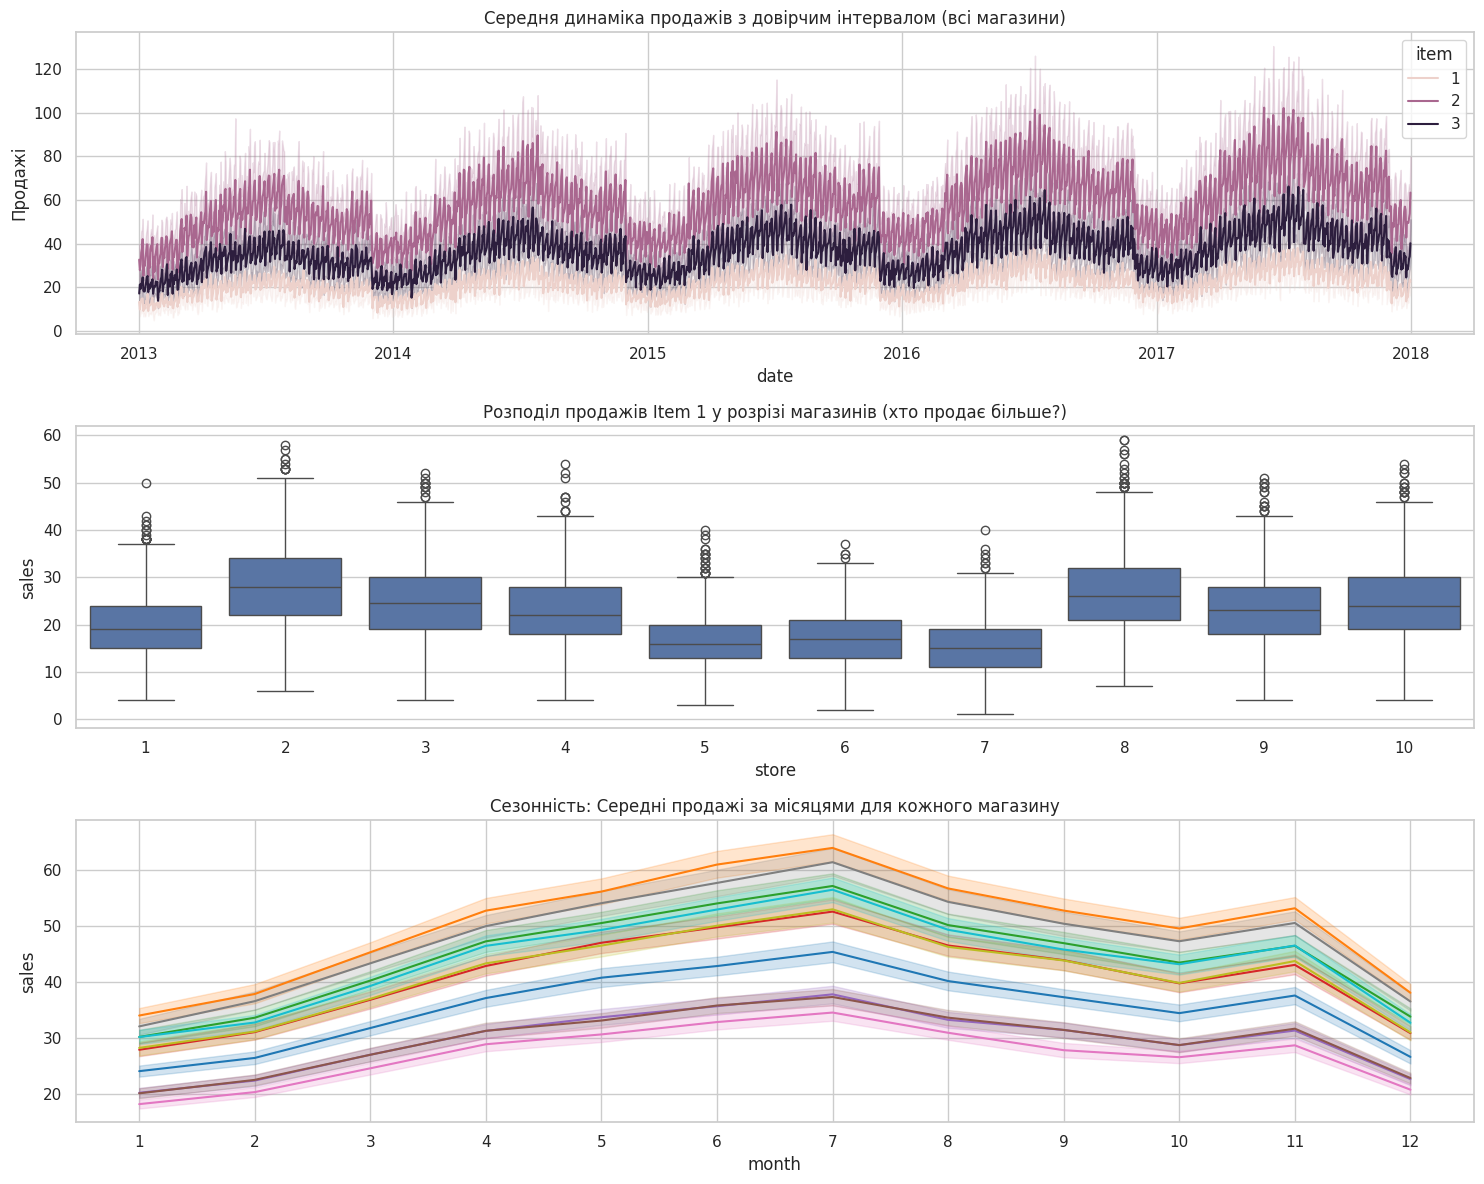

In [ ]:
items_to_show = [1, 2, 3]
df_subset = df[df['item'].isin(items_to_show)].reset_index()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

plt.subplot(3, 1, 1)
sns.lineplot(data=df_subset, x='date', y='sales', hue='item', errorbar=('ci', 100))
plt.title('Середня динаміка продажів з довірчим інтервалом (всі магазини)')
plt.ylabel('Продажі')

plt.subplot(3, 1, 2)
sns.boxplot(data=df[df['item'] == 1].reset_index(), x='store', y='sales')
plt.title('Розподіл продажів Item 1 у розрізі магазинів (хто продає більше?)')

df_subset['month'] = df_subset['date'].dt.month
plt.subplot(3, 1, 3)
sns.lineplot(data=df_subset, x='month', y='sales', hue='store', palette='tab10', legend=False)
plt.title('Сезонність: Середні продажі за місяцями для кожного магазину')
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

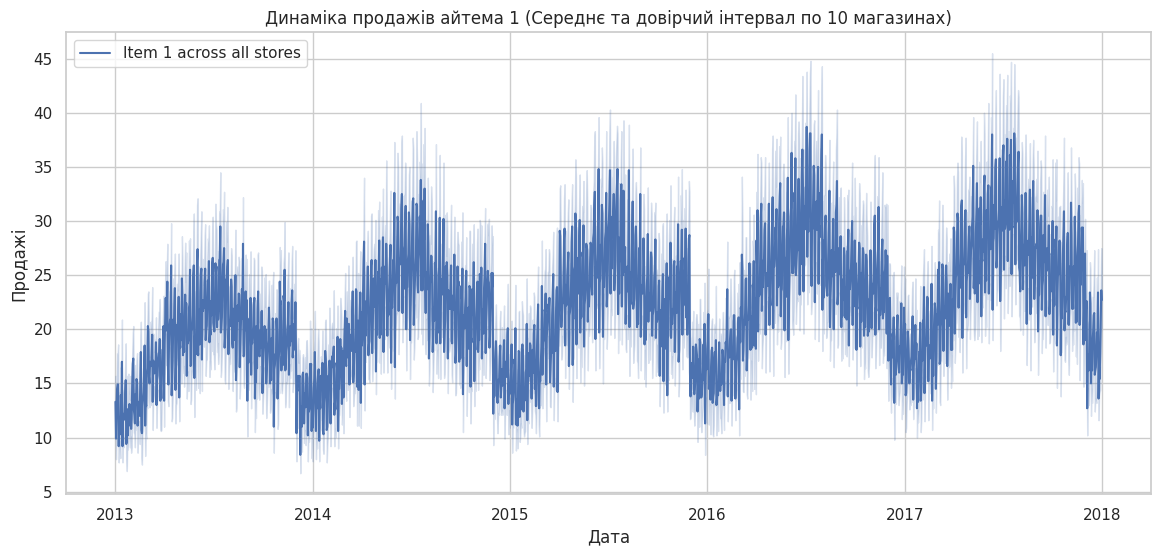

In [ ]:
item_id = 1
data_item = df[df['item'] == item_id].reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=data_item, x='date', y='sales', label=f'Item {item_id} across all stores')
plt.title(f'Динаміка продажів айтема {item_id} (Середнє та довірчий інтервал по 10 магазинах)')
plt.ylabel('Продажі')
plt.xlabel('Дата')
plt.show()

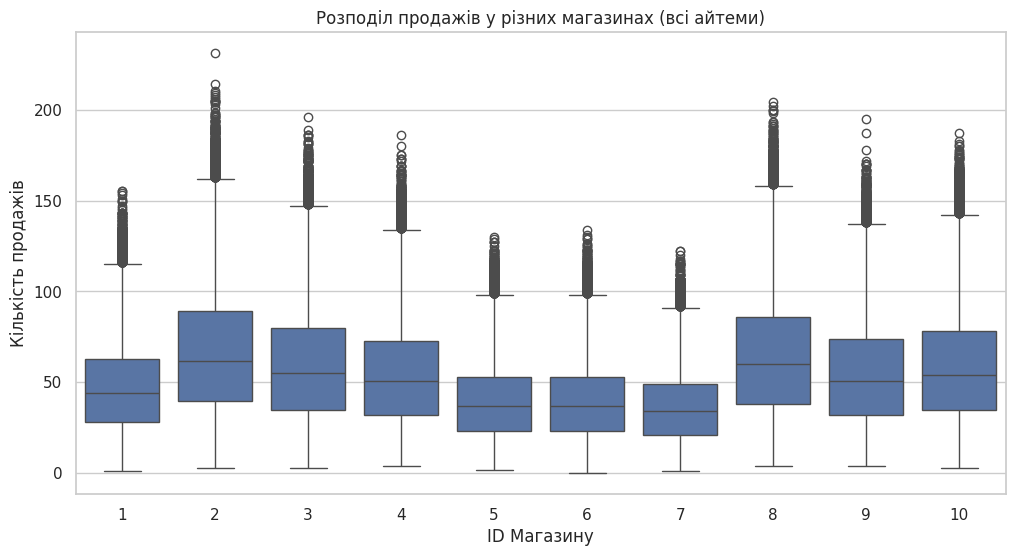

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.reset_index(), x='store', y='sales')
plt.title('Розподіл продажів у різних магазинах (всі айтеми)')
plt.ylabel('Кількість продажів')
plt.xlabel('ID Магазину')
plt.show()

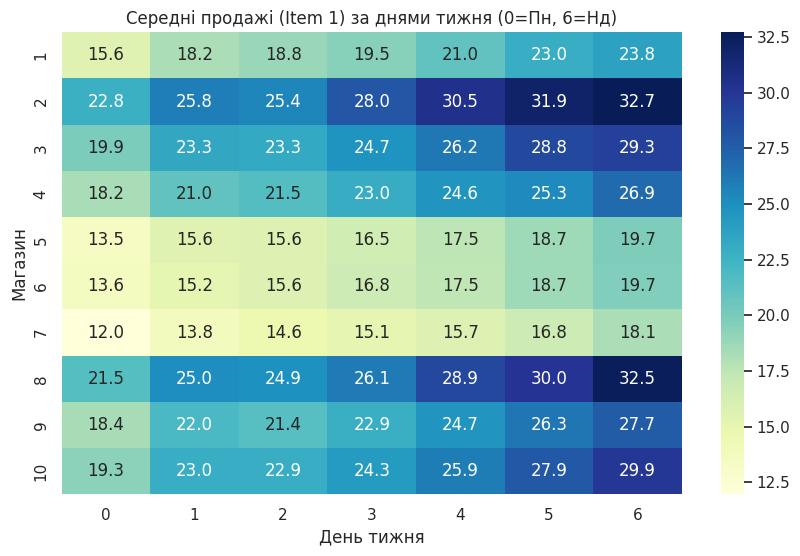

In [ ]:
# Додамо колонку дня тижня
df_pivot = df[df['item'] == 1].copy()
df_pivot['day_of_week'] = df_pivot.index.dayofweek

# Групуємо: середні продажі для кожного магазину по днях тижня
pivot_table = df_pivot.pivot_table(index='store', columns='day_of_week', values='sales', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='YlGnBu')
plt.title('Середні продажі (Item 1) за днями тижня (0=Пн, 6=Нд)')
plt.xlabel('День тижня')
plt.ylabel('Магазин')
plt.show()

## Аналіз динаміки продажів (Спостереження):

Багаторівнева сезонність:

  - Річна циклічність: Чітко виражений сезонний пік у літні місяці та закономірне зниження попиту в зимовий період. Це свідчить про адитивну або мультиплікативну річну сезонність

  - Тижнева циклічність: Продажі демонструють стабільний патерн у межах тижня — активність зростає ближче до вихідних, досягаючи піку в суботу та неділю

Стійкий висхідний тренд:

  - Протягом усього 5-річного періоду для товарів (зокрема item #1) спостерігається певне лінійне зростання обсягів продажів. Це означає, що ринок або популярність товарів розширюється, і модель прогнозування має враховувати цей дрифт (drift)

Гомогенність динаміки по магазинах:

  - Попри різний "базовий рівень" продажів (наприклад, магазини №2 та №8 мають значно вищий обіг, ніж інші), характер коливань залишається ідентичним

  - Синхронність піків та падінь у всіх 10 магазинах підтверджує, що зовнішні фактори (свята, сезони) впливають на всю мережу однаково

**Висновки для моделювання:**

*Оскільки патерни (сезонність і тренд) повторюються для всіх магазинів і товарів, це дає можливість використовувати глобальні моделі (навчені на всіх даних одночасно), що значно підвищить точність прогнозу для окремих позицій.*

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [ ]:
subset_df = df[(df['store'] == 1) & (df['item'] == 1)].reset_index()
subset_df = subset_df.sort_values('date')

series = TimeSeries.from_dataframe(
    subset_df,
    time_col='date',
    value_cols='sales',
    freq='D'
)

print(f"Тип об'єкта: {type(series)}")
print(f"Компоненти: {series.components}")
print(f"Тривалість: {series.start_time()} --- {series.end_time()}")

Тип об'єкта: <class 'darts.timeseries.TimeSeries'>
Компоненти: Index(['sales'], dtype='object')
Тривалість: 2013-01-01 00:00:00 --- 2017-12-31 00:00:00


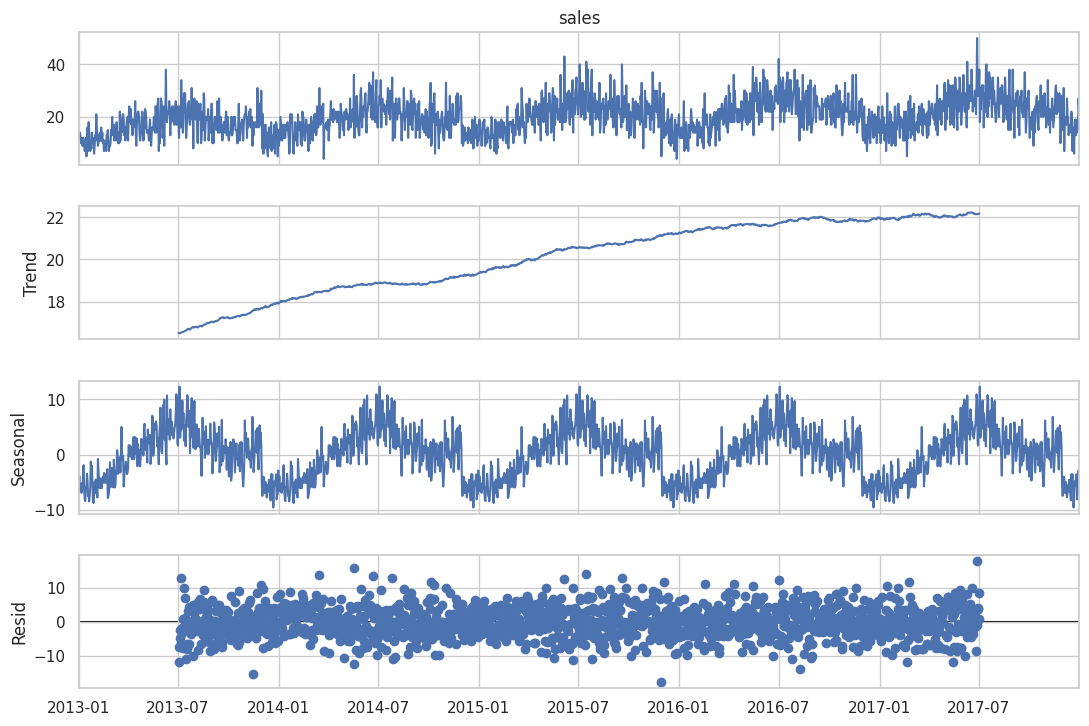

In [ ]:
res = seasonal_decompose(subset_df.set_index('date')['sales'], model='additive', period=365)

fig = res.plot()
fig.set_size_inches(12, 8)

## Спостереження:

  1. Тренд: Чітко видно поступове зростання продажів з ~15 до ~25 одиниць на день протягом 5 років

  2. Сезонність: Спостерігається сильний річний цикл. Продажі досягають максимуму в липні (період відпусток/пік сезону) і падають до мінімуму в січні

  3. Залишки (Resid): Залишки гарно яформовані навколо 0, мають невелике розширення (гетероскедастичність) у місцях сезонних піків (буквально, чим вищі продажі, тим більша варіативність помилки)

----

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [ ]:
series = TimeSeries.from_dataframe(
    subset_df.reset_index(),
    time_col='date',
    value_cols='sales',
    freq='D'
)

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

In [ ]:
train, val = series.split_before(pd.Timestamp('2017-10-01'))

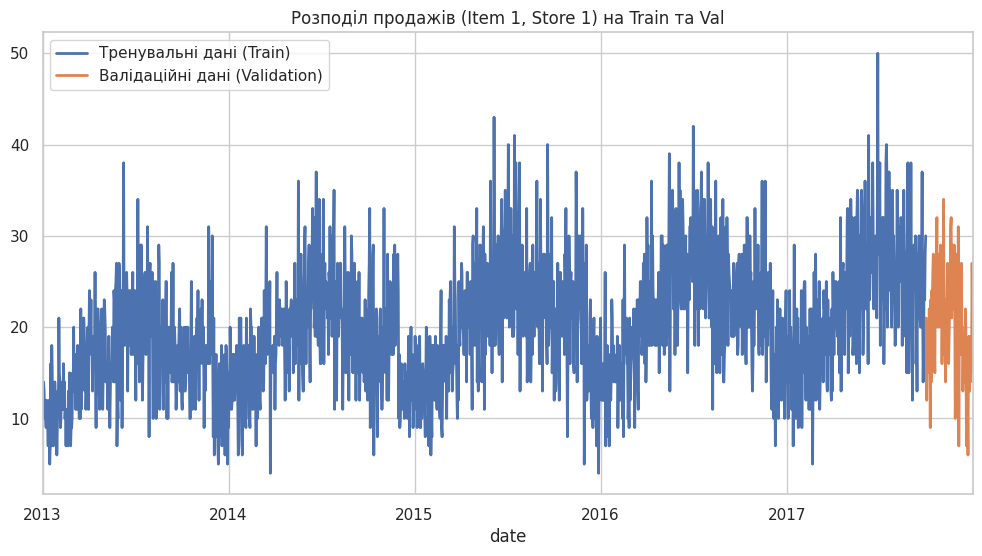

In [ ]:
plt.figure(figsize=(12, 6))
train.plot(label='Тренувальні дані (Train)')
val.plot(label='Валідаційні дані (Validation)')
plt.title('Розподіл продажів (Item 1, Store 1) на Train та Val')
plt.legend()
plt.show()

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1200x500 with 0 Axes>

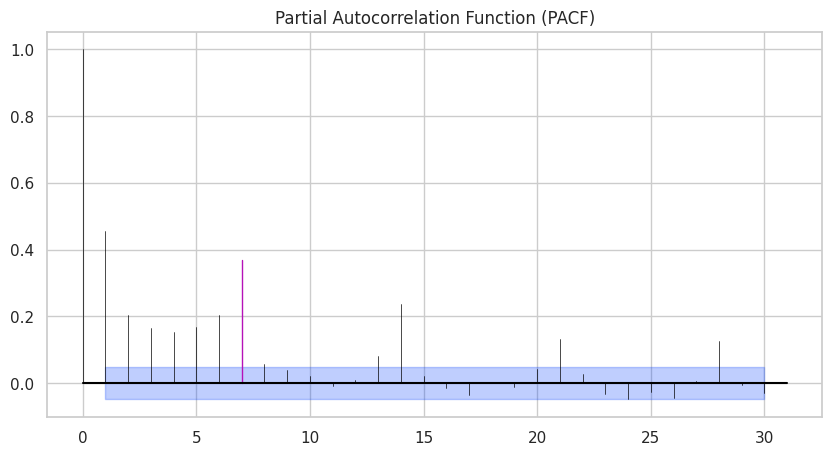

In [ ]:
plt.figure(figsize=(12, 5))
plot_pacf(train, m=7, max_lag=30)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

## Висновки:

Домінування тижневого циклу:

  - Спостереження: Чітко виражені статистично значущі піки на лагах, кратних 7 (7, 14, 21, 28).

  - Інтерпретація: Це підтверджує жорстку тижневу сезонність. Продажі в конкретний день (наприклад, суботу) мають пряму залежність від показників субот попередніх тижнів. Це ключова ознака, яку модель повинна використовувати для прогнозу.

Вплив короткострокової інерції:

  - Спостереження: Лаги 1–6 також залишаються значущими, але демонструють поступове згасання.

  - Інтерпретація: Ряд має сильну авторегресійну складову. Висока значущість першого лагу свідчить про те, що вчорашні продажі є потужним предиктором для сьогоднішніх. Згасання на лагах 2–6 вказує на наявність плавних коливань або сильного тренду, який "зв'язує" сусідні дні між собою.

Стратегія моделювання:

  - Для якісного прогнозування моделі (наприклад, XGBoost) необхідно встановити розмір вікна (lags) не менше 7, щоб охопити повний тижневий цикл.

  - Використання ознак дати (день тижня) буде критично важливим для розділення щоденного шуму та сезонного сигналу.

----


7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [ ]:
# 1. Перевірка тижневої сезонності (m=7)
is_seasonal_7, period_7 = check_seasonality(train, m=7, max_lag=30)
print(f"Тижнева сезонність виявлена: {is_seasonal_7}, період: {period_7}")

# 2. Перевірка річної сезонності (m=365)
is_seasonal_365, period_365 = check_seasonality(train, m=365, max_lag=400)
print(f"Річна сезонність виявлена: {is_seasonal_365}, період: {period_365}")

Тижнева сезонність виявлена: True, період: 7
Річна сезонність виявлена: False, період: 365


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [ ]:
# 1. Сезонна модель: копіює останній повний тиждень (K=7)
seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(len(val))

# 2. Модель дрейфу: враховує загальний нахил тренду
drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(len(val))

# 3. Комбінована модель (Ритм + Тренд)
# Ми додаємо до сезонних коливань приріст, який прогнозує Drift
naive_combined = seasonal_forecast + (drift_forecast - train.last_value())

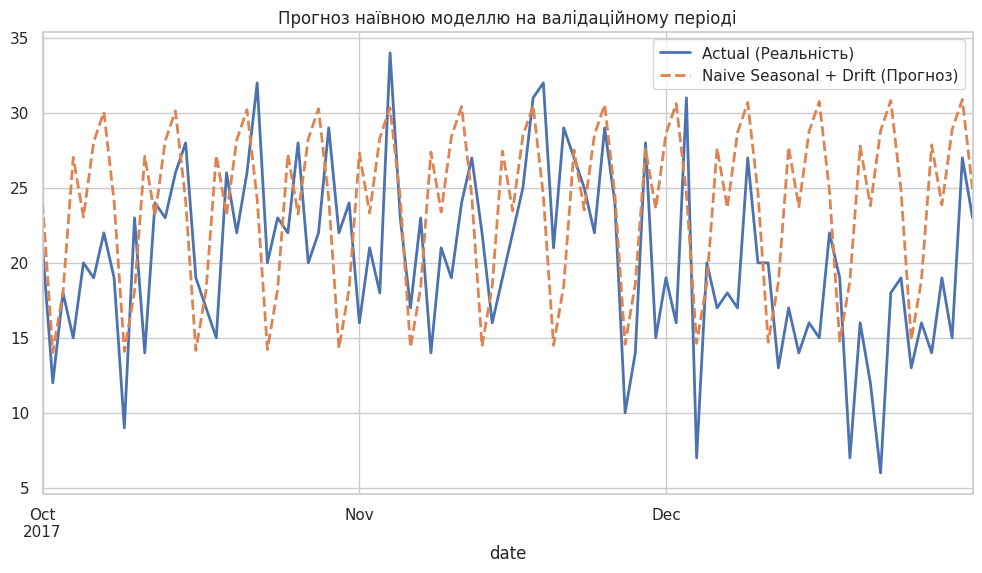

In [ ]:
# Візуалізація
plt.figure(figsize=(12, 6))
val.plot(label='Actual (Реальність)', lw=2)
naive_combined.plot(label='Naive Seasonal + Drift (Прогноз)', ls='--')
plt.title('Прогноз наївною моделлю на валідаційному періоді')
plt.legend()
plt.show()

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [ ]:
naive_mape = mape(val, naive_combined)

print(f"MAPE наївної моделі: {naive_mape:.2f}%")

MAPE наївної моделі: 39.91%


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [ ]:
xgb_model = XGBModel(
    lags=7,
    add_encoders={
        'cyclic': {'future': ['month', 'dayofweek']},
        'datetime_attribute': {'future': ['dayofyear']}
    },
    max_depth=2,
    n_estimators=3000,
    random_state=42
)


xgb_model.fit(train)

xgb_forecast = xgb_model.predict(len(val))

xgb_mape = mape(val, xgb_forecast)

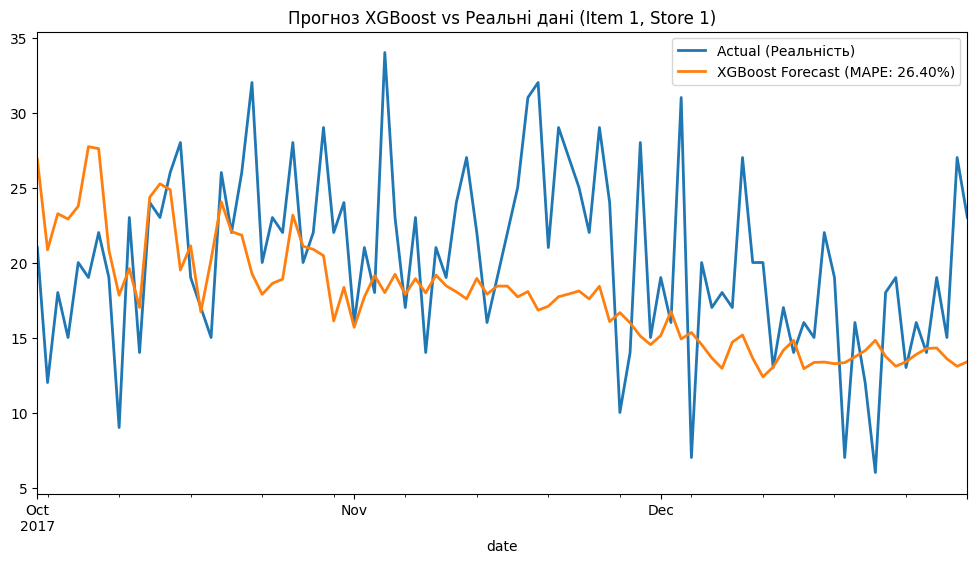

In [ ]:
plt.figure(figsize=(12, 6))
val.plot(label='Actual (Реальність)')
xgb_forecast.plot(label=f'XGBoost Forecast (MAPE: {xgb_mape:.2f}%)')
plt.title(f'Прогноз XGBoost vs Реальні дані (Item 1, Store 1)')
plt.legend()
plt.show()

In [ ]:
print(f"MAPE моделі XGBoost: {xgb_mape:.2f}%")

MAPE моделі XGBoost: 26.40%


11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [ ]:
es_model = ExponentialSmoothing(seasonal_periods=7)

es_model.fit(train)

es_forecast = es_model.predict(len(val))

es_mape = mape(val, es_forecast)

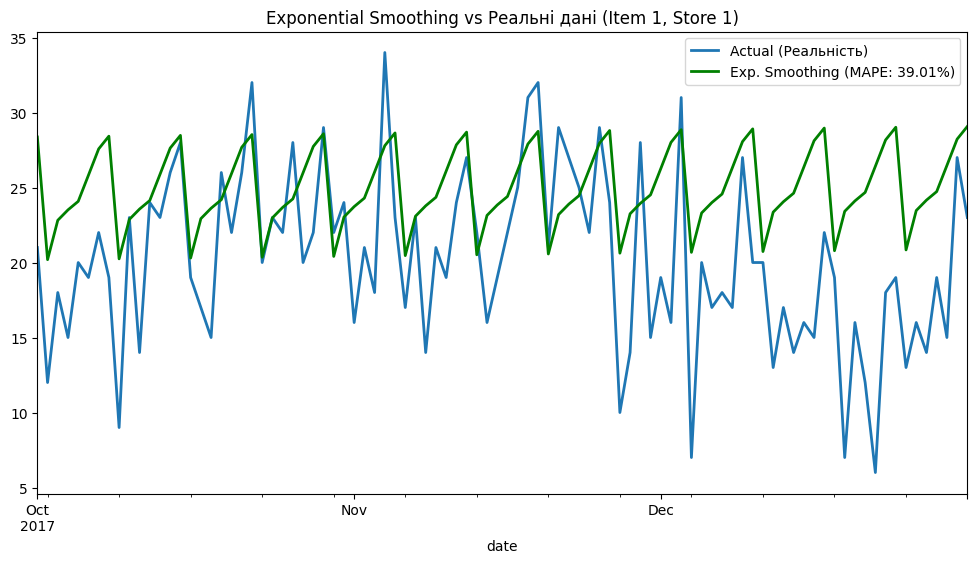

In [ ]:
plt.figure(figsize=(12, 6))
val.plot(label='Actual (Реальність)')
es_forecast.plot(label=f'Exp. Smoothing (MAPE: {es_mape:.2f}%)', color='green')
plt.title(f'Exponential Smoothing vs Реальні дані (Item 1, Store 1)')
plt.legend()
plt.show()

In [ ]:
print(f"MAPE моделі Exponential Smoothing: {es_mape:.2f}%")

MAPE моделі Exponential Smoothing: 39.01%


12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

In [ ]:
arima_model = ARIMA(p=30, d=1, q=1)

arima_model.fit(train)

arima_forecast = arima_model.predict(len(val))

arima_mape = mape(val, arima_forecast)

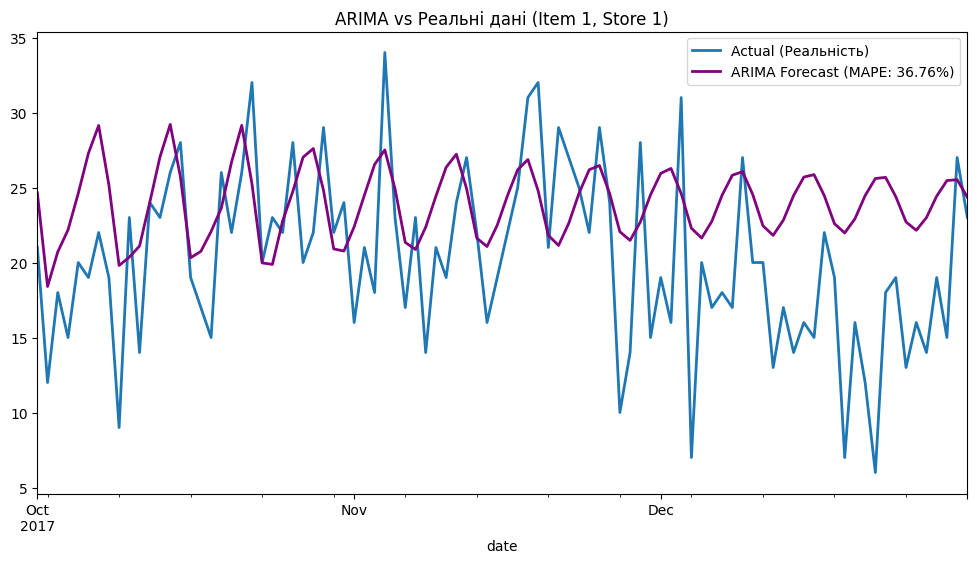

In [ ]:
plt.figure(figsize=(12, 6))
val.plot(label='Actual (Реальність)')
arima_forecast.plot(label=f'ARIMA Forecast (MAPE: {arima_mape:.2f}%)', color='purple')
plt.title(f'ARIMA vs Реальні дані (Item 1, Store 1)')
plt.legend()
plt.show()

In [ ]:
print(f"MAPE моделі ARIMA: {arima_mape:.2f}%")

MAPE моделі ARIMA: 36.76%


Показники приблизно як у базової моделі, можна спробувати пошук оптимальних параметрів

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [ ]:
#?AutoARIMA


In [ ]:
autorima_m = AutoARIMA(season_length=7)
autorima_m.fit(train)

forecast_autorima = autorima_m.predict(len(val))
mape_autorima = mape(val, forecast_autorima)

full_info = autorima_m.model.model_
arma_params = full_info['arma']  # Кортеж: (p, d, q, P, m, D, Q)
p, d, q, P, m, D, Q = arma_params

print("="*60)
print(f"{' РЕЗУЛЬТАТИ ОПТИМІЗАЦІЇ AUTOARIMA ':#^60}")
print("="*60)

print(f"\n✅ Знайдено оптимальну модель: SARIMA({p}, {d}, {q})({P}, {D}, {Q})[{m}]")

print(f"\n{'Компонент':<25} | {'Параметр':<10} | {'Значення'}")
print("-" * 55)
print(f"{'Авторегресія (AR)':<25} | {'p':<10} | {p}")
print(f"{'Інтеграція (Trend)':<25} | {'d':<10} | {d}")
print(f"{'Ковзне середнє (MA)':<25} | {'q':<10} | {q}")
print("-" * 55)
print(f"{'Сезонна AR':<25} | {'P':<10} | {P}")
print(f"{'Сезонна інтеграція':<25} | {'D':<10} | {D}")
print(f"{'Сезонна MA':<25} | {'Q':<10} | {Q}")
print(f"{'Період сезонності':<25} | {'m':<10} | {m} (тижнева)")

print("\n" + "="*60)
print(f"📊 MAPE на валідації: {mape_autorima:.2f}%")
print(f"📉 AIC (критерій): {full_info['aic']:.2f}")
print("="*60)

############# РЕЗУЛЬТАТИ ОПТИМІЗАЦІЇ AUTOARIMA #############

✅ Знайдено оптимальну модель: SARIMA(4, 1, 0)(2, 1, 0)[7]

Компонент                 | Параметр   | Значення
-------------------------------------------------------
Авторегресія (AR)         | p          | 4
Інтеграція (Trend)        | d          | 1
Ковзне середнє (MA)       | q          | 0
-------------------------------------------------------
Сезонна AR                | P          | 2
Сезонна інтеграція        | D          | 1
Сезонна MA                | Q          | 0
Період сезонності         | m          | 7 (тижнева)

📊 MAPE на валідації: 40.56%
📉 AIC (критерій): 10574.40


14. Натренуйте модель Prophet та зробіть висновок про її якість.

In [ ]:
prophet_model = Prophet()

prophet_model.fit(train)

prophet_forecast = prophet_model.predict(len(val))

prophet_mape = mape(val, prophet_forecast)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


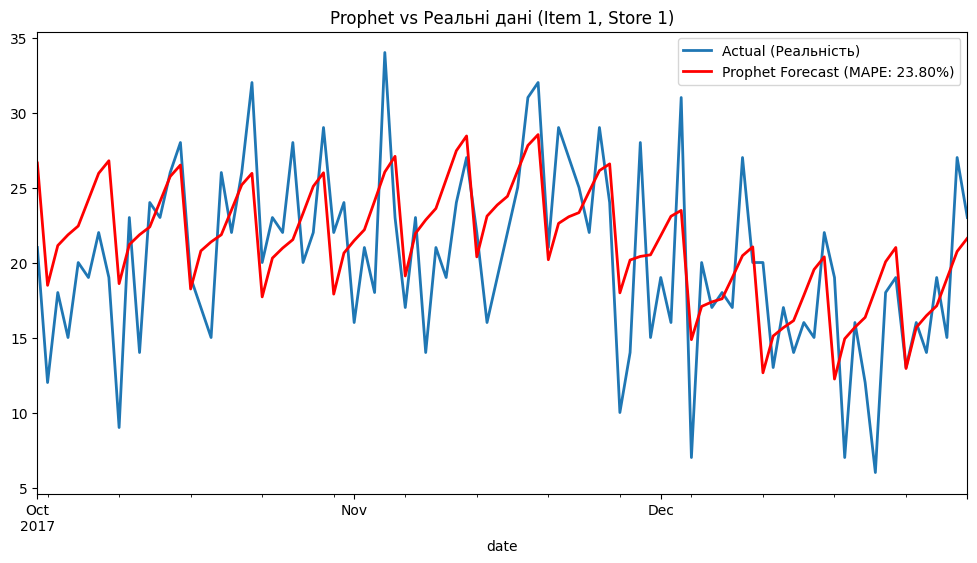

In [ ]:
plt.figure(figsize=(12, 6))
val.plot(label='Actual (Реальність)')
prophet_forecast.plot(label=f'Prophet Forecast (MAPE: {prophet_mape:.2f}%)', color='red')
plt.title(f'Prophet vs Реальні дані (Item 1, Store 1)')
plt.legend()
plt.show()

In [ ]:
print(f"MAPE моделі Prophet: {prophet_mape:.2f}%")

MAPE моделі Prophet: 23.80%


15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [ ]:
from darts.dataprocessing.transformers import Scaler

scaler = Scaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)

rnn_model = RNNModel(
    model="RNN",
    input_chunk_length=14,
    training_length=20,
    n_epochs=100,
    random_state=42
)

rnn_model.fit(train_scaled)

rnn_forecast_scaled = rnn_model.predict(len(val))
rnn_forecast = scaler.inverse_transform(rnn_forecast_scaled)


rnn_mape = mape(val, rnn_forecast)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | RNN              | 700    | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
726       Trainable params
0         Non-trainable params
726       Total params
0.003     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

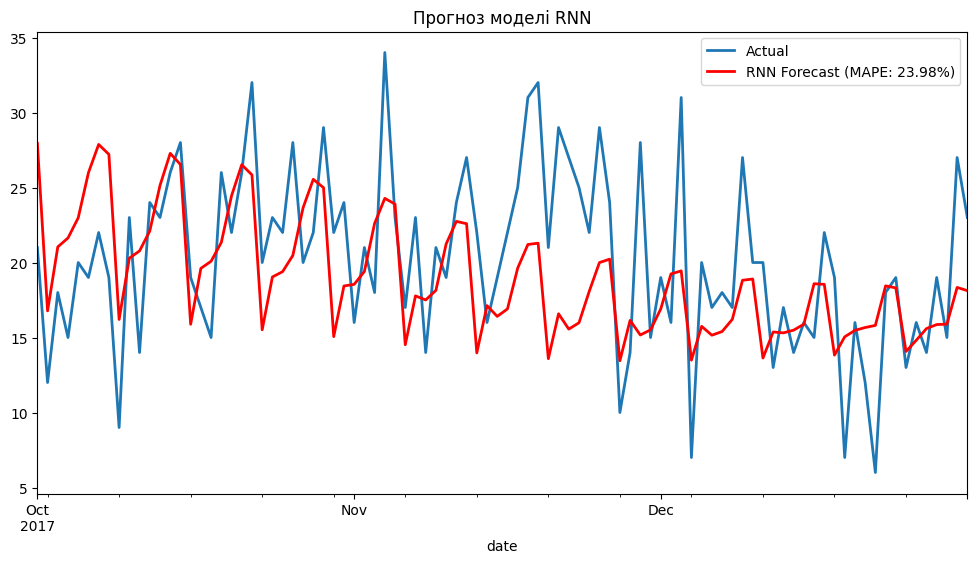

In [ ]:
plt.figure(figsize=(12, 6))
val.plot(label='Actual')
rnn_forecast.plot(label=f'RNN Forecast (MAPE: {rnn_mape:.2f}%)', color='red')
plt.title('Прогноз моделі RNN')
plt.legend()
plt.show()

In [ ]:
print(f"MAPE моделі RNN: {rnn_mape:.2f}%")

MAPE моделі RNN: 23.98%


16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [ ]:
best_model = prophet_model

backtest_forecast = best_model.historical_forecasts(
    series,
    start=series.end_time() - pd.DateOffset(years=1),
    forecast_horizon=30,
    stride=30,
    retrain=True,
    verbose=True
)

backtest_mape = mape(series, backtest_forecast)

historical forecasts: 100%|██████████| 12/12 [00:09<00:00,  1.27it/s]


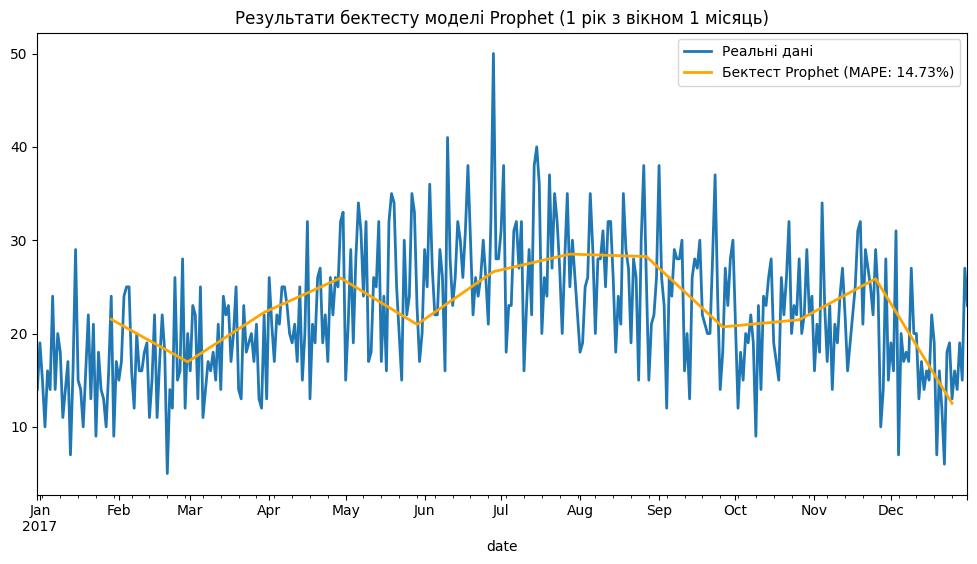

In [ ]:
plt.figure(figsize=(12, 6))
series[series.end_time() - pd.DateOffset(years=1):].plot(label='Реальні дані')
backtest_forecast.plot(label=f'Бектест Prophet (MAPE: {backtest_mape:.2f}%)', color='orange')
plt.title('Результати бектесту моделі Prophet (1 рік з вікном 1 місяць)')
plt.legend()
plt.show()

In [ ]:
print(f"Середня точність MAPE на бектесті: {backtest_mape:.2f}%")

Середня точність MAPE на бектесті: 14.73%


Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Мій підхід базувався б на переході від локальних моделей до глобальних, оскільки підтримка 500 окремих моделей (наприклад, ARIMA чи Prophet) для кожної пари «товар-магазин» є операційно складною та ресурсомісткою (хоча й можна виграти по якості).

**Мій вибір:**

1. Основний варіант: Одна глобальна нейромережа RNN/LSTM для всіх 500 рядів.

    - *Профіт: найкраще вловлює складні нелінійні зв'язки та «запам'ятовує» довгострокові патерни. Глобальний підхід дозволяє моделі вчитися на спільних трендах усіх магазинів одночасно*

2. Альтернатива (Light-версія): градієнтний бустинг (XGBoost/LightGBM) з неглибокими деревами.

    - *Профіт: менш ресурсовитратний варіант, який може майже не поступаєтися у точності, але набагато швидший у навчанні та легший у налаштуванні*


**Обґрунтування:**


Масштабованість: Набагато легше моніторити та оновлювати 1 якісну глобальну модель, ніж сотні окремих.

Cold Start: Глобальні моделі краще працюють із новими товарами, оскільки можуть «запозичувати» знання про сезонність у схожих айтемів.

Ефективність: Використання спільних ознак (ID магазину, категорія товару, акції) дає моделі більше контексту для точного прогнозу.